# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from cycler import cycler

# Higher-resolution plotting for clearer notebook figures.
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 180
plt.rcParams['savefig.dpi'] = 300

# Fixed color palette
PALETTE = ['#04CB93', '#E79F00', '#FE6F93', '#0072B3', '#C3C3C3', '#000000']
plt.rcParams['axes.prop_cycle'] = cycler(color=PALETTE)

FIGURE_DIR = Path('notebook/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams['lines.linewidth'] = 2.6
plt.rcParams['lines.markersize'] = 10


# Setup

In [2]:
def register_error_exponent(n_logical, T_arch, T_char):
    return n_logical * T_arch / T_char

def register_fidelity(n_logical, T_arch, T_char):
    return np.exp(-register_error_exponent(n_logical, T_arch, T_char))

def register_error_rate(n_logical, T_arch, T_char):
    return 1 - register_fidelity(n_logical, T_arch, T_char)

def overhead(m, x):
    return m * x


## Surface code

In [3]:
# space overhead
magic_space_overhead_factor = 1
compilation_space_overhead_factor = 1

def surface_code_n_memory(distance):
    return 2 * distance**2 - 1

def surface_code_n_overhead(distance):
    n_memory = surface_code_n_memory(distance)
    n_overhead = n_memory * magic_space_overhead_factor * compilation_space_overhead_factor
    return n_overhead


In [4]:
# time overhead
magic_time_overhead_factor = 2
compilation_time_overhead_factor = 2

T_gate_factor = 1e3

def surface_code_T(T_gate_count, distance, t_cycle):
    return T_gate_count * distance * t_cycle

def total_T_gates(T, sim_T, T_gate_factor):
    return T / sim_T * T_gate_factor

### Surface-code logical-lifetime anchors

The surface-code comparison treats the quoted distance-3 logical lifetime as the anchor for the conservative suppression factor $\Lambda=2$ only. For a different suppression factor, the distance-3 anchor is recalculated from the standard scaling of logical error per cycle,

$\epsilon_d \propto (p/p_\mathrm{thr})^{(d+1)/2} = \Lambda^{-(d+1)/2}$.

Since logical lifetime is inversely proportional to logical error rate, the distance-3 lifetime for a new $\Lambda$ is

$T_{3}(\Lambda) = T_{3}(\Lambda_0) (\Lambda/\Lambda_0)^2$, with $\Lambda_0=2$.

The lifetime at general distance is then

$T_d(\Lambda) = T_3(\Lambda) \Lambda^{(d-3)/2}$.

This avoids forcing all $\Lambda$ traces to share the same distance-3 point; stronger suppression factors also imply a better distance-3 logical lifetime under the same scaling law.


In [5]:
# error rate
# Phenomenological logical lifetime scaling for the distance-d surface code.
# The d=3 lifetime is anchored at reference_Lambda. Other Lambda values infer
# the d=3 lifetime from epsilon_d proportional to Lambda^(-(d + 1) / 2).
def surface_code_Tlogical(distance, Lambda, Tlogical_3, reference_Lambda=2):
    Tlogical_3_for_Lambda = Tlogical_3 * (Lambda / reference_Lambda)**2
    return Tlogical_3_for_Lambda * Lambda**((distance - 3) / 2)


# Parameters

## Simulation goal

In [6]:
sim_n = 100 # no. qubit
sim_T = 100 # us

sim_n_list = np.linspace(0, sim_n, 100)
sim_T_list = np.linspace(0, sim_T, 100)

# Surface code

In [7]:
Lambda = 4
# This notebook uses a single surface-code operating point backed out from a
# realistic distance-13 logical lifetime estimate.
distances = [13]

T1 = 100
T_char_raw = 5
T_char_surface_3 = 100  # d=3 anchor for Lambda=2

# QEP/EPS characteristic coherence assumptions. The central case is the 2*T1
# limit after eliminating pure dephasing.
T_char_qep_values = [1 * T1, 2 * T1, 4 * T1]


In [8]:
# Fixed surface-code estimates
n_logical_grid = sim_n_list[:, None]
sim_T_grid = sim_T_list[None, :]

n_surface_dict = {d: overhead(surface_code_n_overhead(d), sim_n_list) for d in distances}
T_surface_dict = {d: surface_code_T(total_T_gates(sim_T_list, sim_T, T_gate_factor), d, 1) for d in distances}
T_surface_grid_dict = {d: surface_code_T(total_T_gates(sim_T_grid, sim_T, T_gate_factor), d, 1) for d in distances}
T_char_surface_dict = {d: surface_code_Tlogical(d, Lambda, T_char_surface_3) for d in distances}
error_rate_surface_dict = {
    d: register_error_rate(n_logical_grid, T_surface_grid_dict[d], T_char_surface_dict[d])
    for d in distances
}

surface_estimates = {
    'n': n_surface_dict,
    'T': T_surface_dict,
    'T_grid': T_surface_grid_dict,
    'T_char': T_char_surface_dict,
    'error_rate': error_rate_surface_dict,
}


# Raw

In [9]:
m_n_raw = 1
m_T_raw = 1


In [10]:
# Fixed raw estimates
n_raw_list = overhead(m_n_raw, sim_n_list)
T_raw_list = overhead(m_T_raw, sim_T_list)
T_raw_grid = overhead(m_T_raw, sim_T_grid)
error_rate_raw_grid = register_error_rate(n_logical_grid, T_raw_grid, T_char_raw)

raw_estimates = {
    'n': n_raw_list,
    'T': T_raw_list,
    'T_grid': T_raw_grid,
    'T_char': T_char_raw,
    'error_rate': error_rate_raw_grid,
}


## QEP

In [11]:
m_n_qep = 2
m_T_qep = 2


In [12]:
qep_estimates_by_T_char_qep = {}

for T_char_qep in T_char_qep_values:
    n_qep_list = overhead(m_n_qep, sim_n_list)
    T_qep_list = overhead(m_T_qep, sim_T_list)
    T_qep_grid = sim_T_grid
    error_rate_qep_grid = register_error_rate(n_logical_grid, T_qep_grid, T_char_qep)

    qep_estimates_by_T_char_qep[T_char_qep] = {
        'n': n_qep_list,
        'T': T_qep_list,
        'T_error_grid': T_qep_grid,
        'T_char': T_char_qep,
        'error_rate': error_rate_qep_grid,
    }


## Selected-point error diagnostics

The table below reports the error exponent and the corresponding register failure probability at the same logical-qubit/time point used in the joint plot.


In [13]:
diagnostic_sim_n_index = 20
diagnostic_sim_T_index = 20

n_diag = sim_n_list[diagnostic_sim_n_index]
T_sim_diag = sim_T_list[diagnostic_sim_T_index]

diagnostic_rows = []

def add_diagnostic_row(label, n_logical, T_error, T_resource, T_char, nT):
    exponent = register_error_exponent(n_logical, T_error, T_char)
    diagnostic_rows.append({
        'scheme': label,
        'n_logical': n_logical,
        'T_error_us': T_error,
        'T_resource_us': T_resource,
        'T_char_us': T_char,
        'error_exponent': exponent,
        'register_error_rate': 1 - np.exp(-exponent),
        'space_time_overhead': nT,
    })

add_diagnostic_row(
    'Raw',
    n_diag,
    raw_estimates['T'][diagnostic_sim_T_index],
    raw_estimates['T'][diagnostic_sim_T_index],
    raw_estimates['T_char'],
    raw_estimates['n'][diagnostic_sim_n_index] * raw_estimates['T'][diagnostic_sim_T_index],
)

for T_char_qep, qep_est in qep_estimates_by_T_char_qep.items():
    add_diagnostic_row(
        f'QEP T_char={T_char_qep:.0f}us',
        n_diag,
        sim_T_list[diagnostic_sim_T_index],
        qep_est['T'][diagnostic_sim_T_index],
        qep_est['T_char'],
        qep_est['n'][diagnostic_sim_n_index] * qep_est['T'][diagnostic_sim_T_index],
    )

for d in distances:
    add_diagnostic_row(
        f'Surface d={d}',
        n_diag,
        surface_estimates['T'][d][diagnostic_sim_T_index],
        surface_estimates['T'][d][diagnostic_sim_T_index],
        surface_estimates['T_char'][d],
        surface_estimates['n'][d][diagnostic_sim_n_index] * surface_estimates['T'][d][diagnostic_sim_T_index],
    )

raw_exponent = diagnostic_rows[0]['error_exponent']

[
    {
        'scheme': row['scheme'],
        'n_logical': round(row['n_logical'], 1),
        'T_error_us': round(row['T_error_us'], 1),
        'T_resource_us': round(row['T_resource_us'], 1),
        'T_char_us': round(row['T_char_us'], 1),
        'error_exponent': round(row['error_exponent'], 3),
        'register_error_rate': round(row['register_error_rate'], 6),
        'exponent_improvement_vs_raw': round(raw_exponent / row['error_exponent'], 1),
        'space_time_overhead': round(row['space_time_overhead'], 1),
    }
    for row in diagnostic_rows
]


[{'scheme': 'Raw',
  'n_logical': 20.2,
  'T_error_us': 20.2,
  'T_resource_us': 20.2,
  'T_char_us': 5,
  'error_exponent': 81.624,
  'register_error_rate': 1.0,
  'exponent_improvement_vs_raw': 1.0,
  'space_time_overhead': 408.1},
 {'scheme': 'QEP T_char=100us',
  'n_logical': 20.2,
  'T_error_us': 20.2,
  'T_resource_us': 40.4,
  'T_char_us': 100,
  'error_exponent': 4.081,
  'register_error_rate': 0.983113,
  'exponent_improvement_vs_raw': 20.0,
  'space_time_overhead': 1632.5},
 {'scheme': 'QEP T_char=200us',
  'n_logical': 20.2,
  'T_error_us': 20.2,
  'T_resource_us': 40.4,
  'T_char_us': 200,
  'error_exponent': 2.041,
  'register_error_rate': 0.87005,
  'exponent_improvement_vs_raw': 40.0,
  'space_time_overhead': 1632.5},
 {'scheme': 'QEP T_char=400us',
  'n_logical': 20.2,
  'T_error_us': 20.2,
  'T_resource_us': 40.4,
  'T_char_us': 400,
  'error_exponent': 1.02,
  'register_error_rate': 0.639515,
  'exponent_improvement_vs_raw': 80.0,
  'space_time_overhead': 1632.5},
 {'

# Plots

## Space overhead

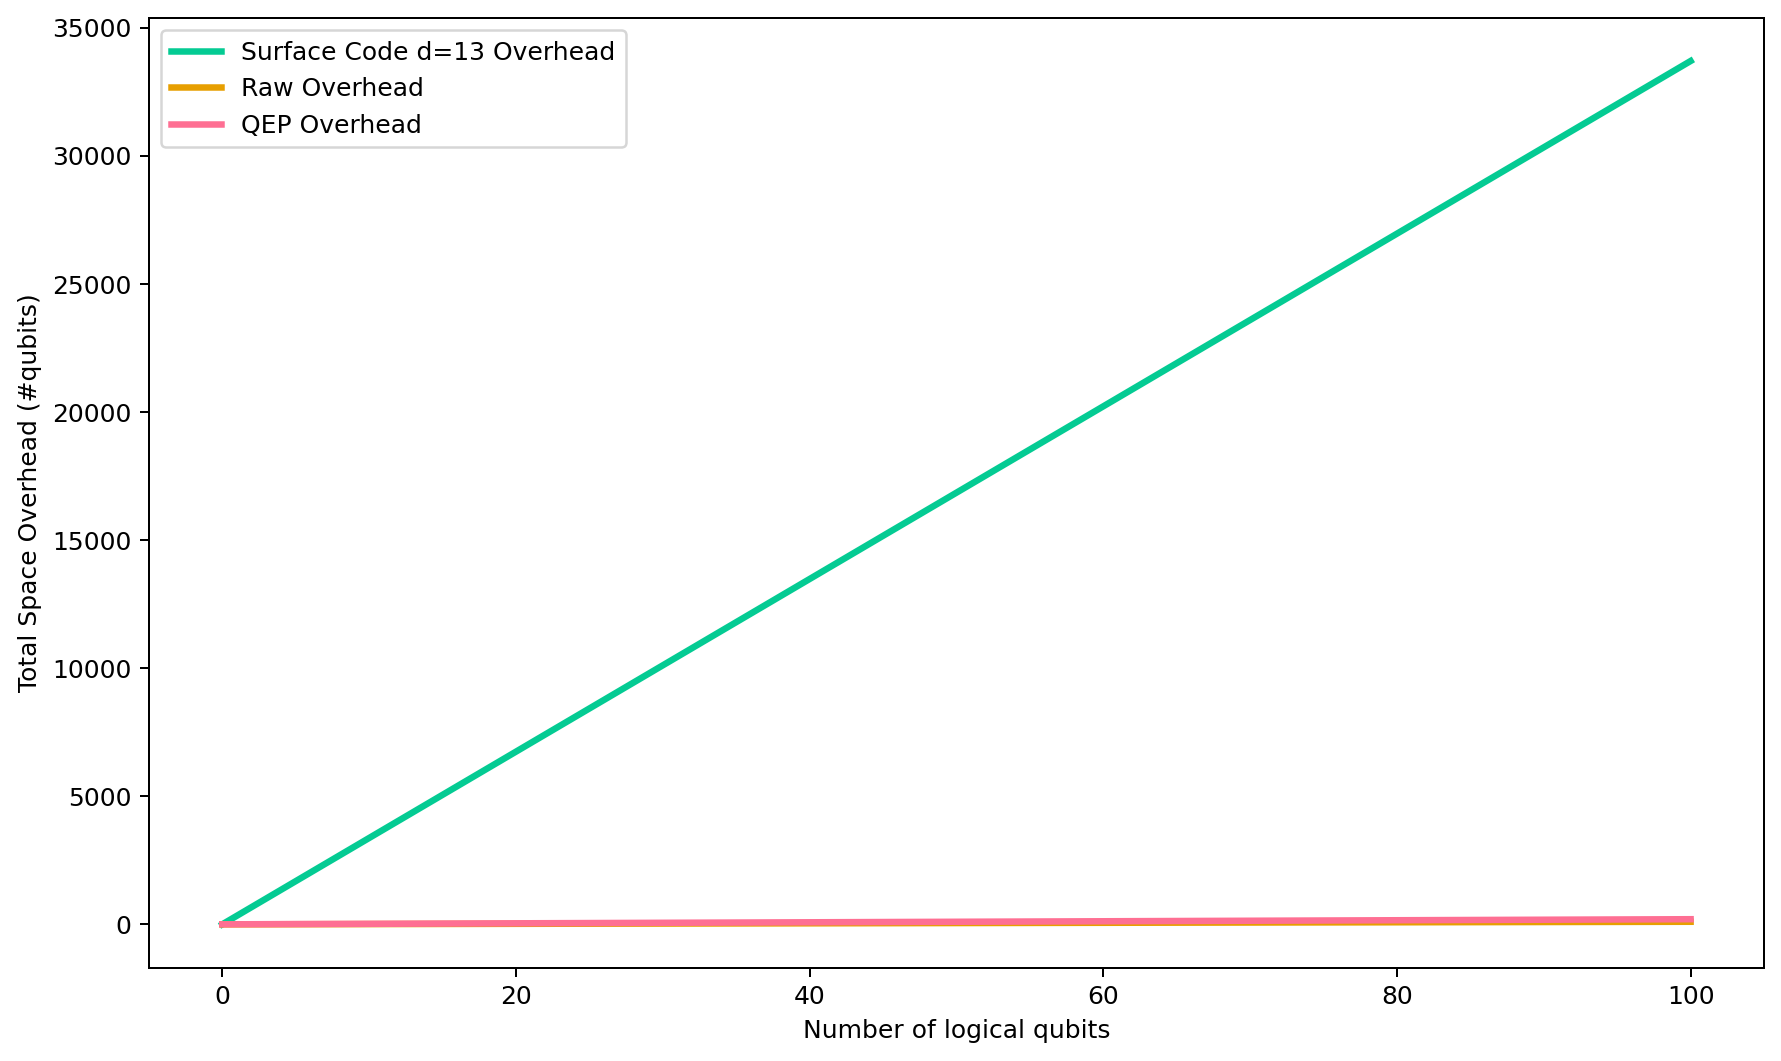

In [14]:
for d, T in surface_estimates['T'].items():
    plt.plot(sim_n_list, surface_estimates['n'][d], label=f'Surface Code d={d} Overhead')

plt.plot(sim_n_list, raw_estimates['n'], label='Raw Overhead')
plt.plot(sim_n_list, qep_estimates_by_T_char_qep[T_char_qep_values[0]]['n'], label='QEP Overhead')

plt.xlabel('Number of logical qubits')
plt.ylabel('Total Space Overhead (#qubits)')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'space_overhead.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Time overhead

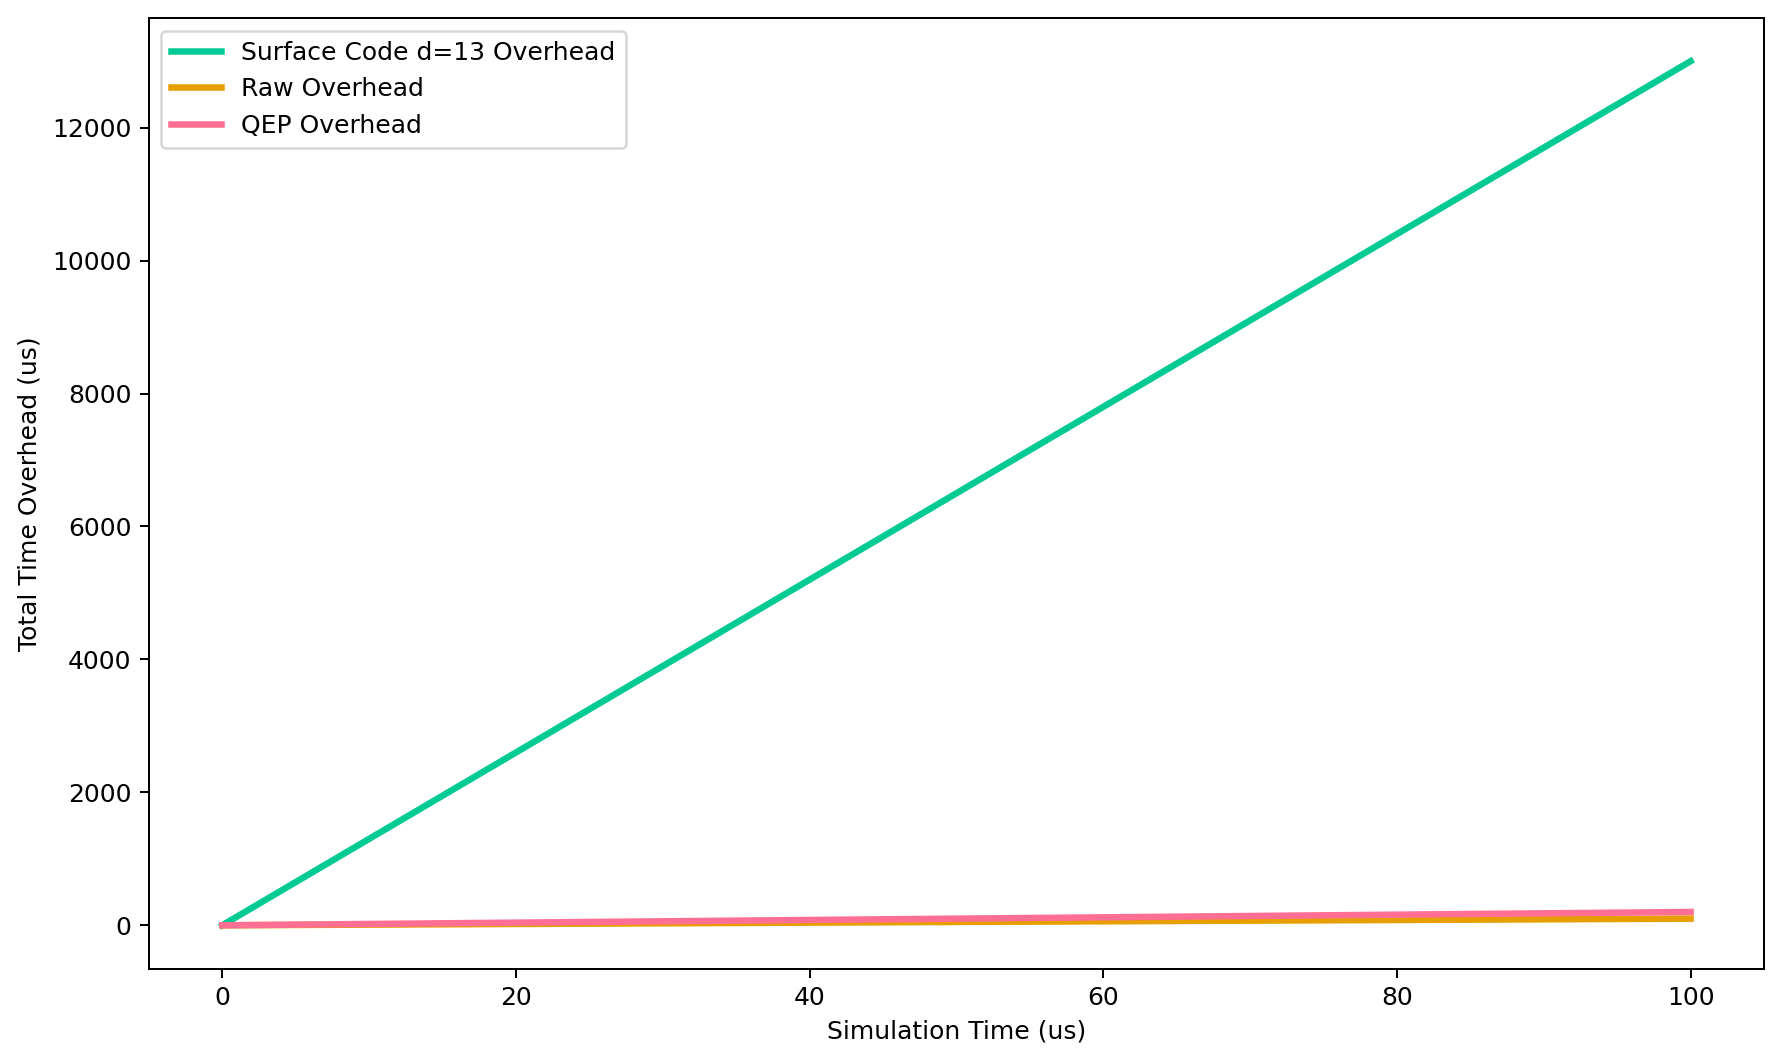

In [15]:
for d, T in surface_estimates['T'].items():
    plt.plot(sim_T_list, T, label=f'Surface Code d={d} Overhead')

plt.plot(sim_T_list, raw_estimates['T'], label='Raw Overhead')
plt.plot(sim_T_list, qep_estimates_by_T_char_qep[T_char_qep_values[0]]['T'], label='QEP Overhead')

plt.xlabel('Simulation Time (us)')
plt.ylabel('Total Time Overhead (us)')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'time_overhead.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Register error rate

This uses a phenomenological register failure probability

$P_\mathrm{fail} = 1 - \exp[-n_\mathrm{logical} T_\mathrm{err} / T_\mathrm{char}]$,

where $T_\mathrm{err}$ is the time over which errors accumulate. For the raw analog and QEP/EPS cases, the interaction dynamics are assumed to run at the bare analog simulation time, so $T_\mathrm{err}=T_\mathrm{sim}$ even though QEP has a separate space-time resource overhead. For the surface-code case, $T_\mathrm{err}$ is the surface-code architecture runtime. Any local error is treated as a full-simulation failure because the XY dynamics spread errors across the register. Lifetime improvements appear linearly in the exponent only in the small-error regime; once $nT_\mathrm{err}/T_\mathrm{char} \gtrsim 1$, the plotted failure probability saturates toward 1.


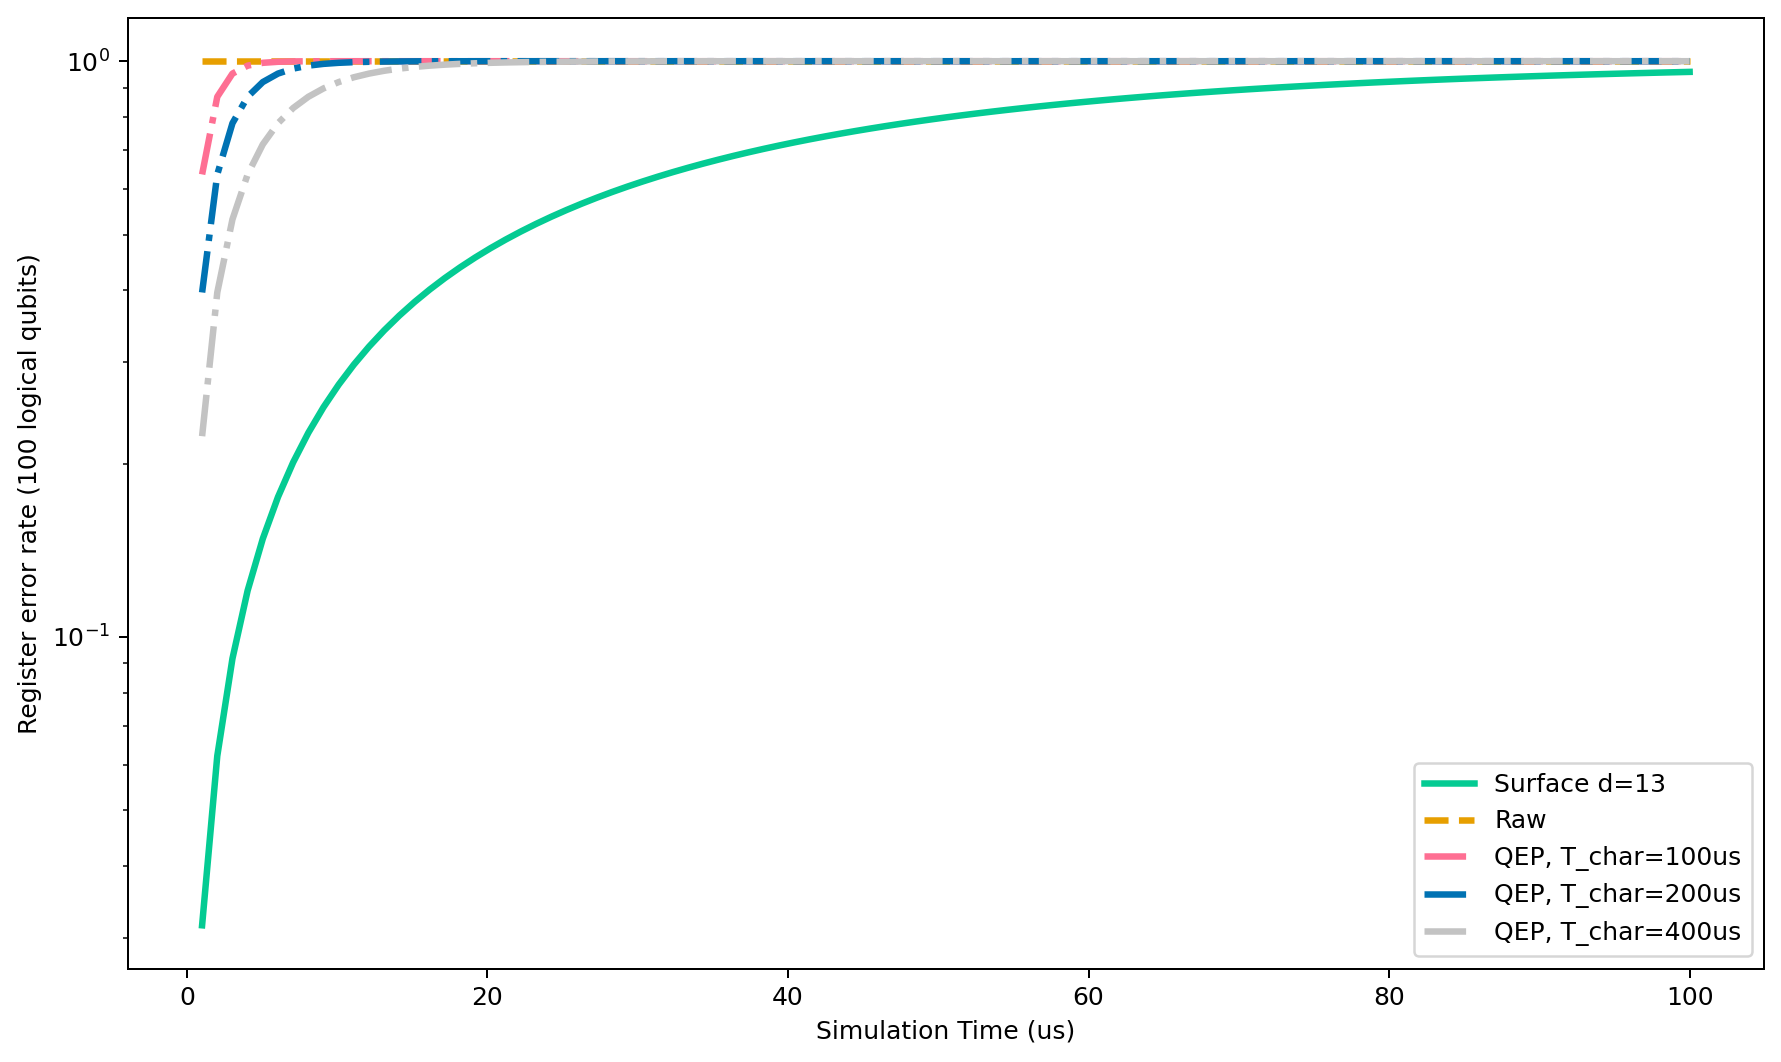

In [16]:
error_rate_plot_n_index = -1
error_rate_plot_n = sim_n_list[error_rate_plot_n_index]
time_mask = sim_T_list > 0

for d in distances:
    plt.plot(
        sim_T_list[time_mask],
        surface_estimates['error_rate'][d][error_rate_plot_n_index, time_mask],
        label=f'Surface d={d}'
    )

plt.plot(
    sim_T_list[time_mask],
    raw_estimates['error_rate'][error_rate_plot_n_index, time_mask],
    '--',
    label='Raw'
)

for T_char_qep, qep_est in qep_estimates_by_T_char_qep.items():
    plt.plot(
        sim_T_list[time_mask],
        qep_est['error_rate'][error_rate_plot_n_index, time_mask],
        '-.',
        label=f'QEP, T_char={T_char_qep:.0f}us'
    )

plt.xlabel('Simulation Time (us)')
plt.ylabel(f'Register error rate ({error_rate_plot_n:.0f} logical qubits)')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'error_rate.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Joint plot

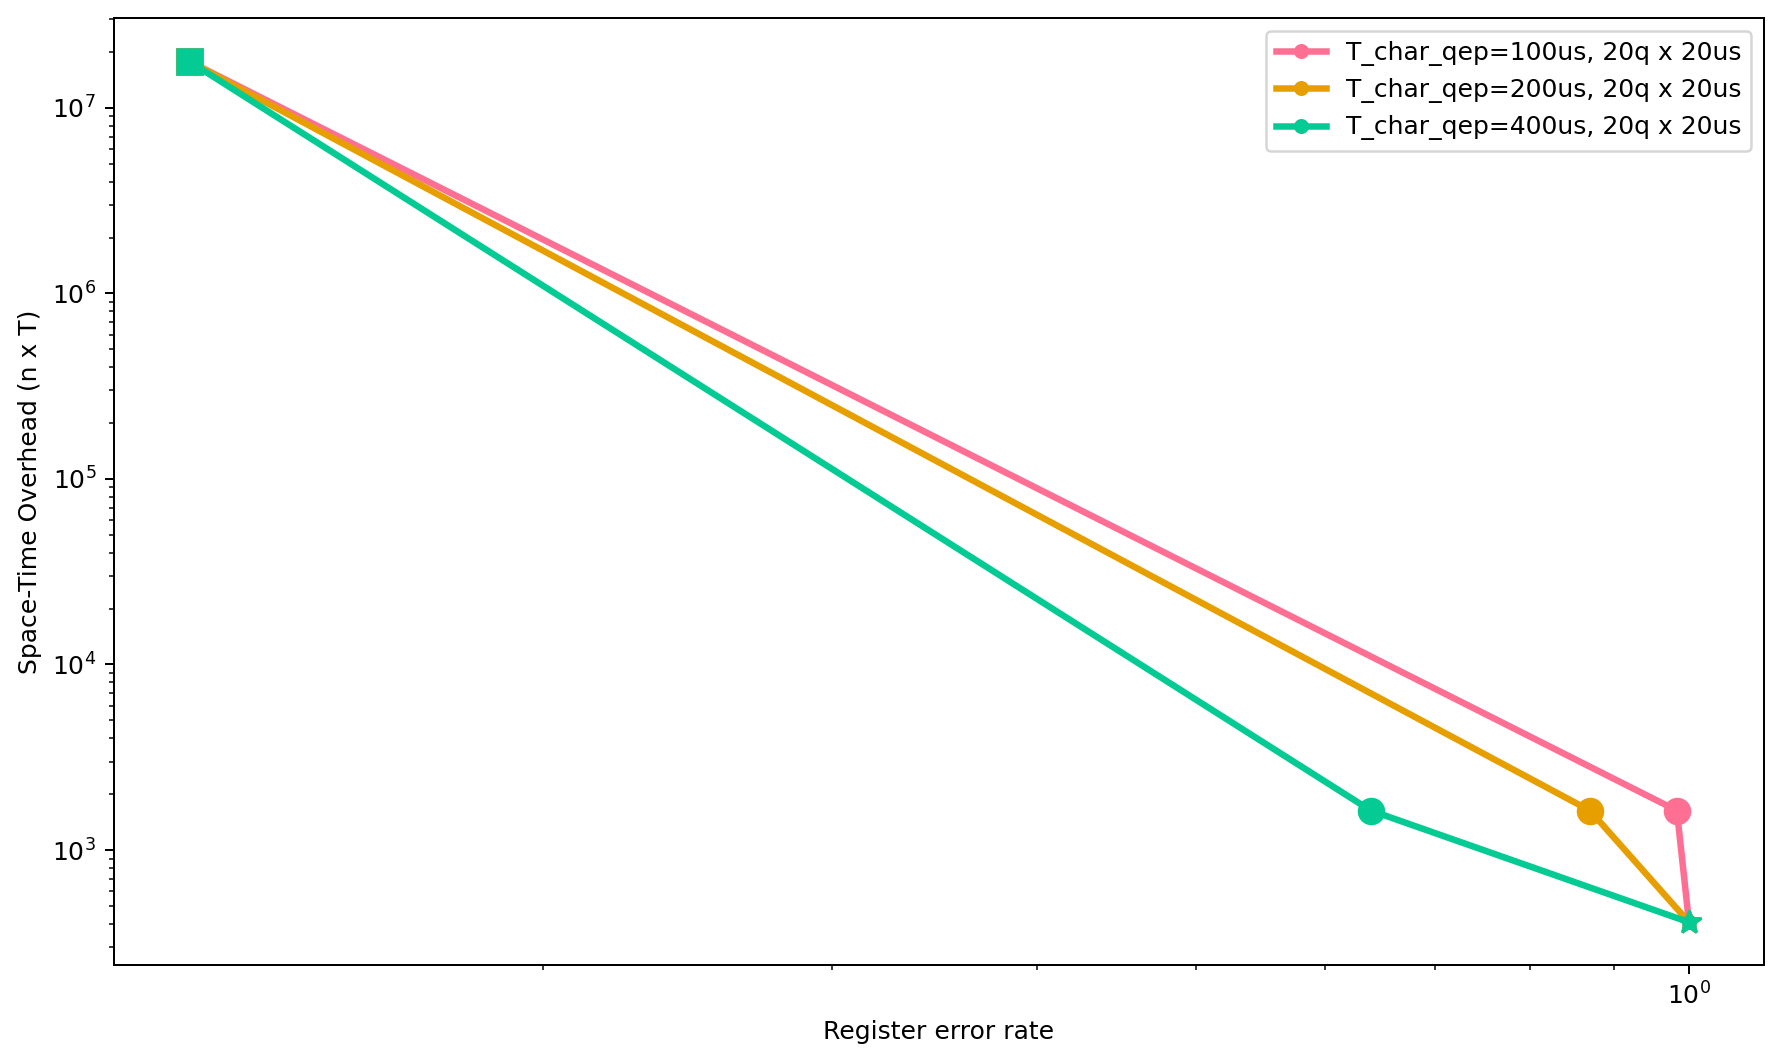

In [17]:
sim_T_indices = [20]
sim_n_indices = [20]

colors = ['#FE6F93', '#E79F00', '#04CB93']
marker_by_scheme = {'surface': 's', 'qep': 'o', 'raw': '*'}

for i, T_char_qep in enumerate(T_char_qep_values):
    qep_est = qep_estimates_by_T_char_qep[T_char_qep]

    for sim_n_index, sim_T_index in zip(sim_n_indices, sim_T_indices):
        error_rates = []
        nTs = []

        for d in distances:
            nT_surface = surface_estimates['n'][d][sim_n_index] * surface_estimates['T'][d][sim_T_index]
            error_rate_surface = surface_estimates['error_rate'][d][sim_n_index, sim_T_index]
            error_rates.append(error_rate_surface)
            nTs.append(nT_surface)

            plt.plot([error_rate_surface], [nT_surface], marker_by_scheme['surface'], color=colors[i])
            # if i == 0 and sim_n_index == sim_n_indices[0] and sim_T_index == sim_T_indices[0]:
            #     plt.annotate(
            #         f'Surface d={d}',
            #         (error_rate_surface, nT_surface),
            #         textcoords='offset points',
            #         xytext=(-10, 10 + 5 * (d - min(distances))),
            #         ha='right',
            #         color='#C3C3C3'
            #     )

        nT_qep = qep_est['n'][sim_n_index] * qep_est['T'][sim_T_index]
        error_rate_qep = qep_est['error_rate'][sim_n_index, sim_T_index]
        error_rates.append(error_rate_qep)
        nTs.append(nT_qep)
        plt.plot([error_rate_qep], [nT_qep], marker_by_scheme['qep'], color=colors[i])
        # if i == 0 and sim_n_index == sim_n_indices[0] and sim_T_index == sim_T_indices[0]:
        #     plt.annotate('QEP', (error_rate_qep, nT_qep), textcoords='offset points', xytext=(0, 10), ha='center', color='#C3C3C3')

        nT_raw = raw_estimates['n'][sim_n_index] * raw_estimates['T'][sim_T_index]
        error_rate_raw = raw_estimates['error_rate'][sim_n_index, sim_T_index]
        error_rates.append(error_rate_raw)
        nTs.append(nT_raw)
        plt.plot([error_rate_raw], [nT_raw], marker_by_scheme['raw'], color=colors[i])
        # if i == 0 and sim_n_index == sim_n_indices[0] and sim_T_index == sim_T_indices[0]:
        #     plt.annotate('Raw', (error_rate_raw, nT_raw), textcoords='offset points', xytext=(0, 10), ha='center', color='#C3C3C3')

        plt.plot(
            error_rates,
            nTs,
            '.-',
            color=colors[i],
            label=f'T_char_qep={T_char_qep:.0f}us, {sim_n_list[sim_n_index]:.0f}q x {sim_T_list[sim_T_index]:.0f}us'
        )

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Register error rate')
plt.ylabel('Space-Time Overhead (n x T)')
# plt.annotate(
#     'Lower error rate, lower overhead',
#     xy=(min(error_rates), min(nTs) / 7),
#     xytext=(0.2, 0.4),
#     textcoords='axes fraction',
#     arrowprops=dict(arrowstyle='->', color='#000000')
# )
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'joint_space_time_error_rate.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Exponent-based comparison

This plot uses the cumulative register error exponent $H = n_\mathrm{logical} T_\mathrm{err} / T_\mathrm{char}$ on the x-axis and keeps the register failure probability $P_\mathrm{fail}=1-e^{-H}$ as the top-axis interpretation. The benchmark is specified by dimensionless analog evolution time $Jt$; raw and QEP convert this to physical analog time using $J^{-1}=25$ ns, while surface code uses the digital gate count needed to implement the same $Jt$. This avoids compressing all high-error cases near $P_\mathrm{fail}=1$ while preserving the lifetime-improvement ratios.


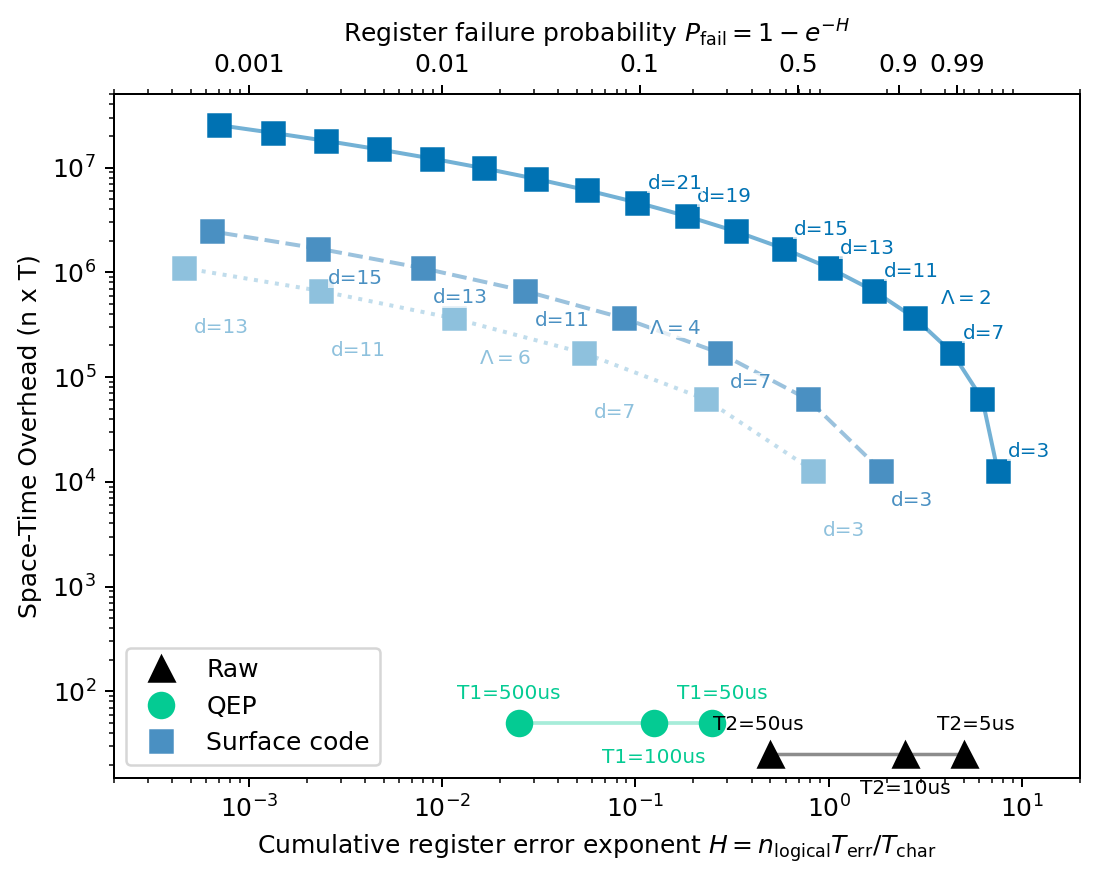

[{'scheme': 'Raw',
  'group': 'Raw',
  'label': 'Raw T2=5us',
  'H': 5.0,
  'P_fail': 0.9932620530009145,
  'nT': 25.0,
  'marker': '^',
  'color': '#000000'},
 {'scheme': 'Raw',
  'group': 'Raw',
  'label': 'Raw T2=10us',
  'H': 2.5,
  'P_fail': 0.9179150013761012,
  'nT': 25.0,
  'marker': '^',
  'color': '#000000'},
 {'scheme': 'Raw',
  'group': 'Raw',
  'label': 'Raw T2=50us',
  'H': 0.5,
  'P_fail': 0.3934693402873666,
  'nT': 25.0,
  'marker': '^',
  'color': '#000000'},
 {'scheme': 'QEP',
  'group': 'QEP',
  'label': 'QEP T1=50us',
  'H': 0.25,
  'P_fail': 0.22119921692859512,
  'nT': 50.0,
  'marker': 'o',
  'color': '#04CB93'},
 {'scheme': 'QEP',
  'group': 'QEP',
  'label': 'QEP T1=100us',
  'H': 0.125,
  'P_fail': 0.11750309741540454,
  'nT': 50.0,
  'marker': 'o',
  'color': '#04CB93'},
 {'scheme': 'QEP',
  'group': 'QEP',
  'label': 'QEP T1=500us',
  'H': 0.025,
  'P_fail': 0.024690087971667385,
  'nT': 50.0,
  'marker': 'o',
  'color': '#04CB93'},
 {'scheme': 'Surface cod

In [21]:
comparison_n = 50
comparison_Jt = 20
J_inv_us = 25e-3
comparison_T = comparison_Jt * J_inv_us
sim_Jt = sim_T / J_inv_us
T_gates_per_Jt = T_gate_factor / sim_Jt
surface_comparison_candidate_distances = list(range(3, 52, 2))
surface_comparison_Lambda_values = [2, 4, 6]
surface_min_H = 1e-3
raw_comparison_T2_values = [5, 10, 50]
qep_comparison_T_char_values = [100, 200, 1_000]

xlim = (2e-4, 20)
ylim = (15, 0.5e8)
annotation_fontsize = 8
raw_comparison_color = '#000000'
qep_comparison_color = '#04CB93'
surface_comparison_colors = {2: '#0072B3', 4: '#4A90C2', 6: '#8EC1DD'}
surface_line_styles = {2: '-', 4: '--', 6: ':'}

comparison_points = []
qep_annotation_offsets = {
    'QEP T1=50us': (4, 8),
    'QEP T1=100us': (0, -10),
    'QEP T1=500us': (-4, 8),
}
raw_annotation_offsets = {
    'Raw T2=5us': (5, 8),
    'Raw T2=10us': (0, -10),
    'Raw T2=50us': (-5, 8),
}
surface_distance_labels = {3, 7, 11, 13, 15, 19, 21}
lambda_label_distance = 9
surface_distance_label_offsets = {
    2: (4, 4),
    4: (4, -8),
    6: (4, -20),
}
label_bbox = dict(facecolor='white', edgecolor='none', alpha=0.72, pad=0.15)
lambda_label_offsets = {
    2: (10, 8),
    4: (10, -4),
    6: (10, -16),
}

def add_comparison_point(scheme, label, H, nT, marker, color, group=None, **extra):
    point = {
        'scheme': scheme,
        'group': group or scheme,
        'label': label,
        'H': H,
        'P_fail': 1 - np.exp(-H),
        'nT': nT,
        'marker': marker,
        'color': color,
    }
    point.update(extra)
    comparison_points.append(point)

nT_raw = overhead(m_n_raw, comparison_n) * overhead(m_T_raw, comparison_T)
for T2_raw_comp in raw_comparison_T2_values:
    H_raw = register_error_exponent(comparison_n, overhead(m_T_raw, comparison_T), T2_raw_comp)
    add_comparison_point('Raw', f'Raw T2={T2_raw_comp:g}us', H_raw, nT_raw, '^', raw_comparison_color)

for T_char_qep in qep_comparison_T_char_values:
    H_qep = register_error_exponent(comparison_n, comparison_T, T_char_qep)
    nT_qep = overhead(m_n_qep, comparison_n) * comparison_T
    add_comparison_point(
        'QEP',
        f'QEP T1={T_char_qep / 2:g}us',
        H_qep,
        nT_qep,
        marker_by_scheme['qep'],
        qep_comparison_color,
    )

for Lambda_surface in surface_comparison_Lambda_values:
    for d in surface_comparison_candidate_distances:
        T_surface = surface_code_T(comparison_Jt * T_gates_per_Jt, d, 1)
        T_char_surface = surface_code_Tlogical(d, Lambda_surface, T_char_surface_3)
        n_surface = surface_code_n_overhead(d) * comparison_n
        H_surface = register_error_exponent(comparison_n, T_surface, T_char_surface)
        nT_surface = n_surface * T_surface
        add_comparison_point(
            'Surface code',
            f'd={d}',
            H_surface,
            nT_surface,
            marker_by_scheme['surface'],
            surface_comparison_colors[Lambda_surface],
            group=f'Surface code Lambda={Lambda_surface}',
            Lambda=Lambda_surface,
            d=d,
        )
        if H_surface <= surface_min_H:
            break

fig, ax = plt.subplots(figsize=(6.2, 5.0))

# Raw trace.
raw_points = [point for point in comparison_points if point['scheme'] == 'Raw']
ax.plot(
    [point['H'] for point in raw_points],
    [point['nT'] for point in raw_points],
    '-',
    color=raw_comparison_color,
    alpha=0.45,
    linewidth=1.4,
)
for point_index, point in enumerate(raw_points):
    ax.plot(point['H'], point['nT'], '^', color=raw_comparison_color, markersize=10, label='Raw' if point_index == 0 else None)
    raw_offset = raw_annotation_offsets[point['label']]
    ax.annotate(
        point['label'].replace('Raw ', ''),
        (point['H'], point['nT']),
        textcoords='offset points',
        xytext=raw_offset,
        ha='center',
        va='bottom' if raw_offset[1] > 0 else 'top',
        fontsize=annotation_fontsize,
        color=raw_comparison_color,
    )

# QEP trace.
qep_points = [point for point in comparison_points if point['scheme'] == 'QEP']
ax.plot(
    [point['H'] for point in qep_points],
    [point['nT'] for point in qep_points],
    '-',
    color=qep_comparison_color,
    alpha=0.35,
    linewidth=1.5,
)
for point_index, point in enumerate(qep_points):
    ax.plot(point['H'], point['nT'], marker_by_scheme['qep'], color=qep_comparison_color, markersize=10, label='QEP' if point_index == 0 else None)
    offset = qep_annotation_offsets[point['label']]
    ax.annotate(
        point['label'].replace('QEP ', ''),
        (point['H'], point['nT']),
        textcoords='offset points',
        xytext=offset,
        ha='center',
        va='bottom' if offset[1] > 0 else 'top',
        fontsize=annotation_fontsize,
        color=qep_comparison_color,
    )

# Surface-code sensitivity traces.
for Lambda_surface in surface_comparison_Lambda_values:
    points = [point for point in comparison_points if point['group'] == f'Surface code Lambda={Lambda_surface}']
    ax.plot(
        [point['H'] for point in points],
        [point['nT'] for point in points],
        linestyle=surface_line_styles[Lambda_surface],
        color=surface_comparison_colors[Lambda_surface],
        alpha=0.55,
        linewidth=1.6,
    )
    for point_index, point in enumerate(points):
        ax.plot(
            point['H'],
            point['nT'],
            marker_by_scheme['surface'],
            color=surface_comparison_colors[Lambda_surface],
            alpha=1.0,
            markersize=9,
            label='Surface code' if Lambda_surface == 4 and point_index == 0 else None,
        )
        if point['d'] in surface_distance_labels and xlim[0] <= point['H'] <= xlim[1]:
            distance_offset = surface_distance_label_offsets[Lambda_surface]
            ax.annotate(
                point['label'],
                (point['H'], point['nT']),
                textcoords='offset points',
                xytext=distance_offset,
                ha='left',
                va='bottom' if distance_offset[1] >= 0 else 'top',
                fontsize=annotation_fontsize,
                color=point['color'],
                bbox=label_bbox,
            )

    lambda_label_point = next(point for point in points if point['d'] == lambda_label_distance)
    ax.annotate(
        rf'$\Lambda={Lambda_surface}$',
        (lambda_label_point['H'], lambda_label_point['nT']),
        textcoords='offset points',
        xytext=lambda_label_offsets[Lambda_surface],
        ha='left',
        va='center',
        fontsize=annotation_fontsize,
        color=surface_comparison_colors[Lambda_surface],
        bbox=label_bbox,
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.margins(x=0.04, y=0.08)
ax.set_xlabel(r'Cumulative register error exponent $H = n_\mathrm{logical}T_\mathrm{err}/T_\mathrm{char}$')
ax.set_ylabel('Space-Time Overhead (n x T)')
ax.legend(loc='lower left', frameon=True)

ax_top = ax.twiny()
ax_top.set_xscale('log')
ax_top.set_xlim(ax.get_xlim())
pfail_ticks = np.array([1e-3, 1e-2, 1e-1, 0.5, 0.9, 0.99])
H_ticks = -np.log1p(-pfail_ticks)
visible = (H_ticks >= ax.get_xlim()[0]) & (H_ticks <= ax.get_xlim()[1])
ax_top.set_xticks(H_ticks[visible])
ax_top.set_xticklabels([f'{tick:g}' for tick in pfail_ticks[visible]])
ax_top.set_xlabel(r'Register failure probability $P_\mathrm{fail}=1-e^{-H}$')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'joint_space_time_error_exponent.pdf', format='pdf', bbox_inches='tight')
plt.show()

comparison_points
